# Dependencies

In [119]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Frequencies

In [120]:
def plot_frequencies(df, title):
    plt.plot(df["f_L"], label="L frequency")
    plt.plot(df["f_F"], label="F frequency")
    plt.plot(df["f_B"], label="B frequency")
    plt.plot(df["f_C"], label="C frequency")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Frequency")
    plt.title(title)

    plt.show()

def plot_env_frequencies(name):
    run0 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_0_generation_records.csv")
    run1 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_1_generation_records.csv")
    run2 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_2_generation_records.csv")

    avg_run = pd.DataFrame()
    avg_run["f_L"] = pd.concat([run0["f_L"], run1["f_L"], run2["f_L"]], axis=1).mean(axis=1)
    avg_run["f_F"] = pd.concat([run0["f_F"], run1["f_F"], run2["f_F"]], axis=1).mean(axis=1)
    avg_run["f_B"] = pd.concat([run0["f_B"], run1["f_B"], run2["f_B"]], axis=1).mean(axis=1)
    avg_run["f_C"] = pd.concat([run0["f_C"], run1["f_C"], run2["f_C"]], axis=1).mean(axis=1)

    plot_frequencies(avg_run, f"Environment {name}, Mean Positional Frequencies")

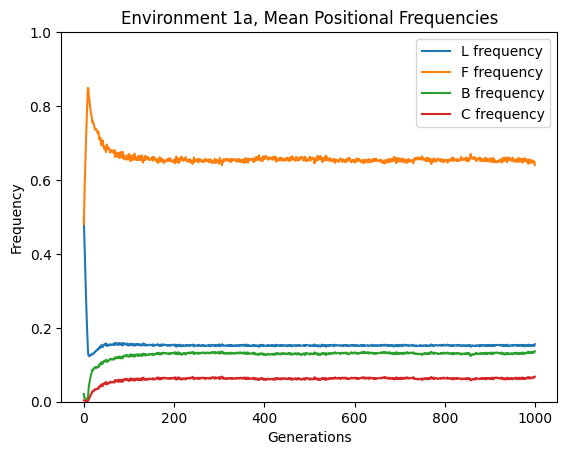

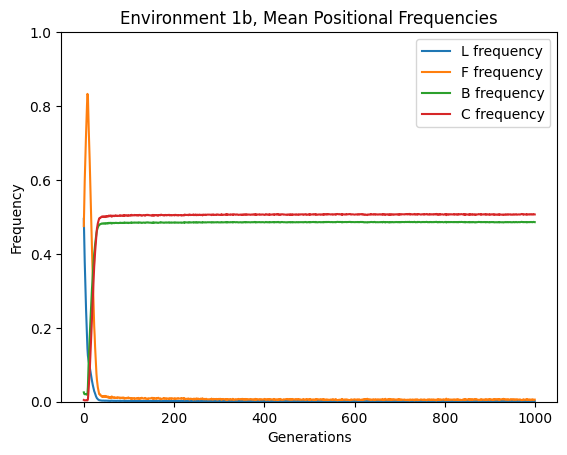

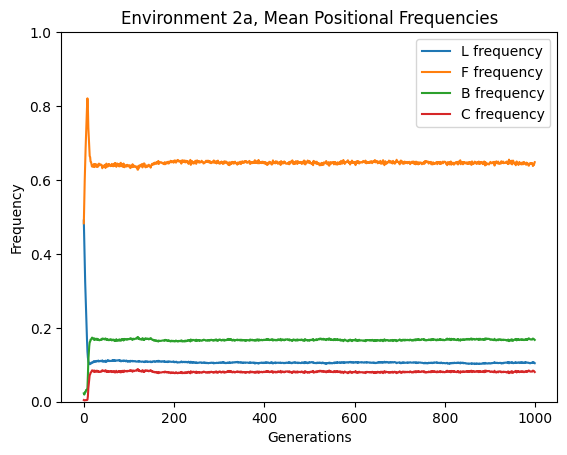

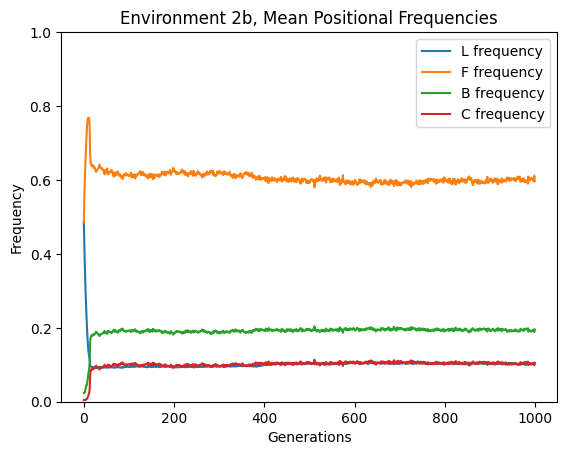

In [121]:
plot_env_frequencies("1a")
plot_env_frequencies("1b")
plot_env_frequencies("2a")
plot_env_frequencies("2b")

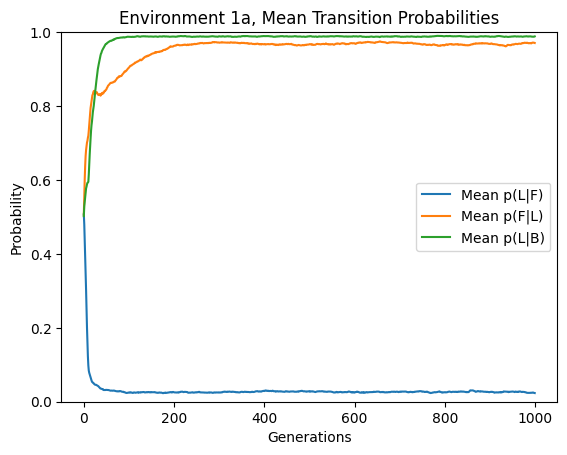

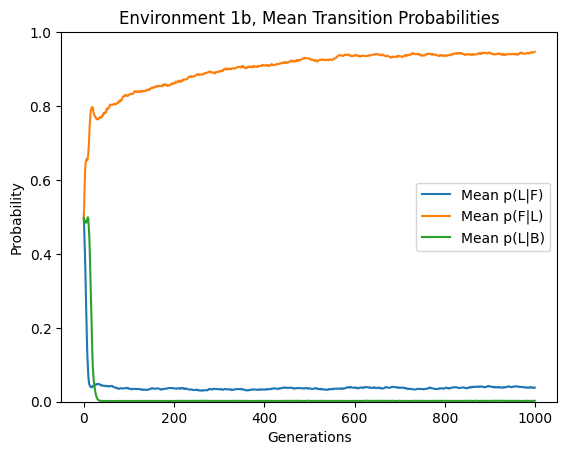

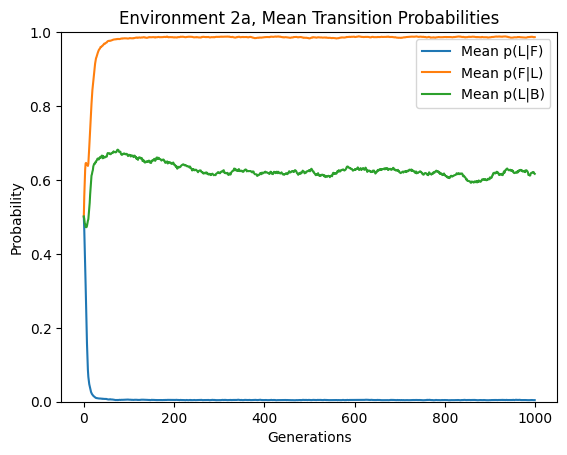

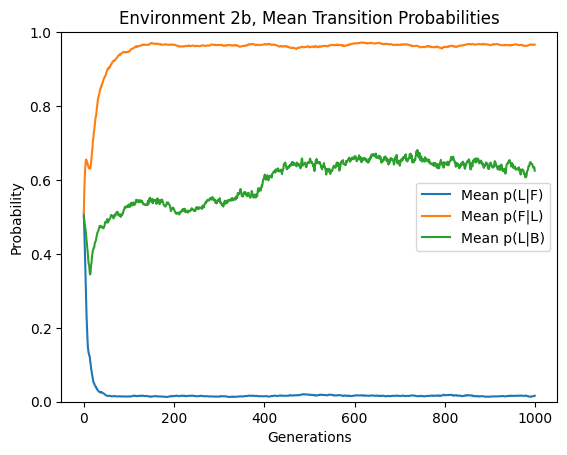

In [122]:
def plot_strategies(df, title):
    plt.plot(df["mean_p_L_given_F"], label="Mean p(L|F)")
    plt.plot(df["mean_p_F_given_L"], label="Mean p(F|L)")
    plt.plot(df["mean_p_L_given_B"], label="Mean p(L|B)")

    plt.legend()
    plt.ylim([0,1])
    plt.xlabel("Generations")
    plt.ylabel("Probability")
    plt.title(title)

    plt.show()

def plot_env_strategies(name):
    run0 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_0_generation_records.csv")
    run1 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_1_generation_records.csv")
    run2 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_2_generation_records.csv")

    avg_run = pd.DataFrame()
    avg_run["mean_p_L_given_F"] = pd.concat([run0["p_L_given_F"], run1["p_L_given_F"], run2["p_L_given_F"]], axis=1).mean(axis=1)
    avg_run["mean_p_F_given_L"] = pd.concat([run0["p_F_given_L"], run1["p_F_given_L"], run2["p_F_given_L"]], axis=1).mean(axis=1)
    avg_run["mean_p_L_given_B"] = pd.concat([run0["p_L_given_B"], run1["p_L_given_B"], run2["p_L_given_B"]], axis=1).mean(axis=1)

    plot_strategies(avg_run, f"Environment {name}, Mean Transition Probabilities")

plot_env_strategies("1a")
plot_env_strategies("1b")
plot_env_strategies("2a")
plot_env_strategies("2b")

In [123]:
RESULTS = {
    "1a": {
        "observed_strategy": [],
        "expected_strategy": [1.000, 0.010, 1.000],
        "observed_frequencies": [],
        "expected_frequencies": [0.160, 0.610, 0.150, 0.080],
        "observed_cm": 0,
        "expected_cm": 0.7700,
    },
    "1b": {
        "observed_strategy": [],
        "expected_strategy": [1.000, 0.000, 0.000],
        "observed_frequencies": [],
        "expected_frequencies": [0.000, 0.000, 0.490, 0.510],
        "observed_cm": 0,
        "expected_cm": 0.0000,
    },
    "2a": {
        "observed_strategy": [],
        "expected_strategy": [1.000, 0.000, 0.270],
        "observed_frequencies": [],
        "expected_frequencies": [0.070, 0.500, 0.260, 0.170],
        "observed_cm": 0,
        "expected_cm": 0.5700,
    },
    "2b": {
        "observed_strategy": [],
        "expected_strategy": [0.940, 0.010, 0.100],
        "observed_frequencies": [],
        "expected_frequencies": [0.040, 0.280, 0.370, 0.310],
        "observed_cm": 0,
        "expected_cm": 0.3100,
    },
}

In [124]:
def fill_results():
    for name in ["1a", "1b", "2a", "2b"]:
        run0 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_0_generation_records.csv")
        run1 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_1_generation_records.csv")
        run2 = pd.read_csv(f"yang_reproduction_outputs/final/figure_{name}_2_generation_records.csv")

        avg_run = pd.DataFrame()
        avg_run["mean_p_L_given_F"] = pd.concat([run0["p_L_given_F"], run1["p_L_given_F"], run2["p_L_given_F"]], axis=1).mean(axis=1)
        avg_run["mean_p_F_given_L"] = pd.concat([run0["p_F_given_L"], run1["p_F_given_L"], run2["p_F_given_L"]], axis=1).mean(axis=1)
        avg_run["mean_p_L_given_B"] = pd.concat([run0["p_L_given_B"], run1["p_L_given_B"], run2["p_L_given_B"]], axis=1).mean(axis=1)

        avg_run["f_L"] = pd.concat([run0["f_L"], run1["f_L"], run2["f_L"]], axis=1).mean(axis=1)
        avg_run["f_F"] = pd.concat([run0["f_F"], run1["f_F"], run2["f_F"]], axis=1).mean(axis=1)
        avg_run["f_B"] = pd.concat([run0["f_B"], run1["f_B"], run2["f_B"]], axis=1).mean(axis=1)
        avg_run["f_C"] = pd.concat([run0["f_C"], run1["f_C"], run2["f_C"]], axis=1).mean(axis=1)


        avg_run["CM"] = pd.concat([run0["CM"], run1["CM"], run2["CM"]], axis=1).mean(axis=1)

        RESULTS[name]["observed_strategy"].append(avg_run["mean_p_F_given_L"].iloc[-1])
        RESULTS[name]["observed_strategy"].append(avg_run["mean_p_L_given_F"].iloc[-1])
        RESULTS[name]["observed_strategy"].append(avg_run["mean_p_L_given_B"].iloc[-1])

        RESULTS[name]["observed_frequencies"].append(avg_run["f_L"].iloc[-1])
        RESULTS[name]["observed_frequencies"].append(avg_run["f_F"].iloc[-1])
        RESULTS[name]["observed_frequencies"].append(avg_run["f_B"].iloc[-1])
        RESULTS[name]["observed_frequencies"].append(avg_run["f_C"].iloc[-1])

        RESULTS[name]["observed_cm"] = avg_run["CM"].iloc[-1]

fill_results()

In [125]:
def autolabel_bars(ax, bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )


def plot_strategy_comparison(results, name, con1, con2):
    figures = list(results.keys())
    x = np.arange(len(figures))
    width = 0.11

    fig, ax = plt.subplots(figsize=(11, 6))

    labels = [
        f"{con1} p(F|L)", f"{con2} p(F|L)",
        f"{con1} p(L|F)", f"{con2} p(L|F)",
        f"{con1} p(L|B)", f"{con2} p(L|B)",
    ]
    offsets = [-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]

    values = []
    for fig_name in figures:
        obs = results[fig_name]["observed_strategy"]
        exp = results[fig_name]["expected_strategy"]
        values.append([obs[0], exp[0], obs[1], exp[1], obs[2], exp[2]])

    values = np.array(values)

    for i, label in enumerate(labels):
        bars = ax.bar(x + offsets[i] * width, values[:, i], width, label=label)
        autolabel_bars(ax, bars)

    ax.set_title(f"{name}: {con1} vs {con2} strategy values")
    ax.set_ylabel("Strategy probability")
    ax.set_xticks(x)
    ax.set_xticklabels(figures)
    ax.set_ylim(0, 1.15)
    ax.legend(ncol=2, fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_frequency_comparison(results, name, con1, con2):
    figures = list(results.keys())
    x = np.arange(len(figures))
    width = 0.08

    fig, ax = plt.subplots(figsize=(12, 6))

    labels = [
        f"{con1} L", f"{con2} L",
        f"{con1} F", f"{con2} F",
        f"{con1} B", f"{con2} B",
        f"{con1} C", f"{con2} C",
    ]
    offsets = [-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]

    values = []
    for fig_name in figures:
        obs = results[fig_name]["observed_frequencies"]
        exp = results[fig_name]["expected_frequencies"]
        values.append([obs[0], exp[0], obs[1], exp[1], obs[2], exp[2], obs[3], exp[3]])

    values = np.array(values)

    for i, label in enumerate(labels):
        bars = ax.bar(x + offsets[i] * width, values[:, i], width, label=label)
        autolabel_bars(ax, bars)

    ax.set_title(f"{name}: {con1} vs {con2} positional frequencies")
    ax.set_ylabel("Position frequency")
    ax.set_xticks(x)
    ax.set_xticklabels(figures)
    ax.set_ylim(0, 0.75)
    ax.legend(ncol=4, fontsize=8)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_cm_comparison(results, name, con1, con2):
    figures = list(results.keys())
    observed = [results[name]["observed_cm"] for name in figures]
    expected = [results[name]["expected_cm"] for name in figures]

    x = np.arange(len(figures))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 6))

    observed_bars = ax.bar(x - width / 2, observed, width, label=f"{con1} CM")
    expected_bars = ax.bar(x + width / 2, expected, width, label=f"{con2} CM")

    autolabel_bars(ax, observed_bars)
    autolabel_bars(ax, expected_bars)

    ax.set_title(f"{name}: {con1} vs {con2} collective mobility")
    ax.set_ylabel("CM = f_L + f_F")
    ax.set_xticks(x)
    ax.set_xticklabels(figures)
    ax.set_ylim(0, 1.0)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

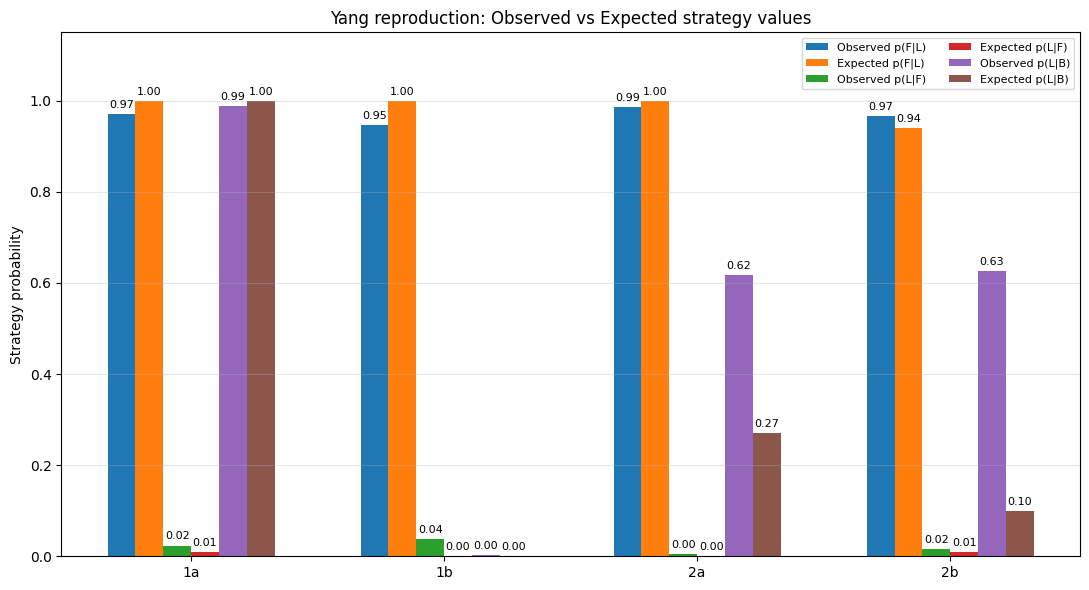

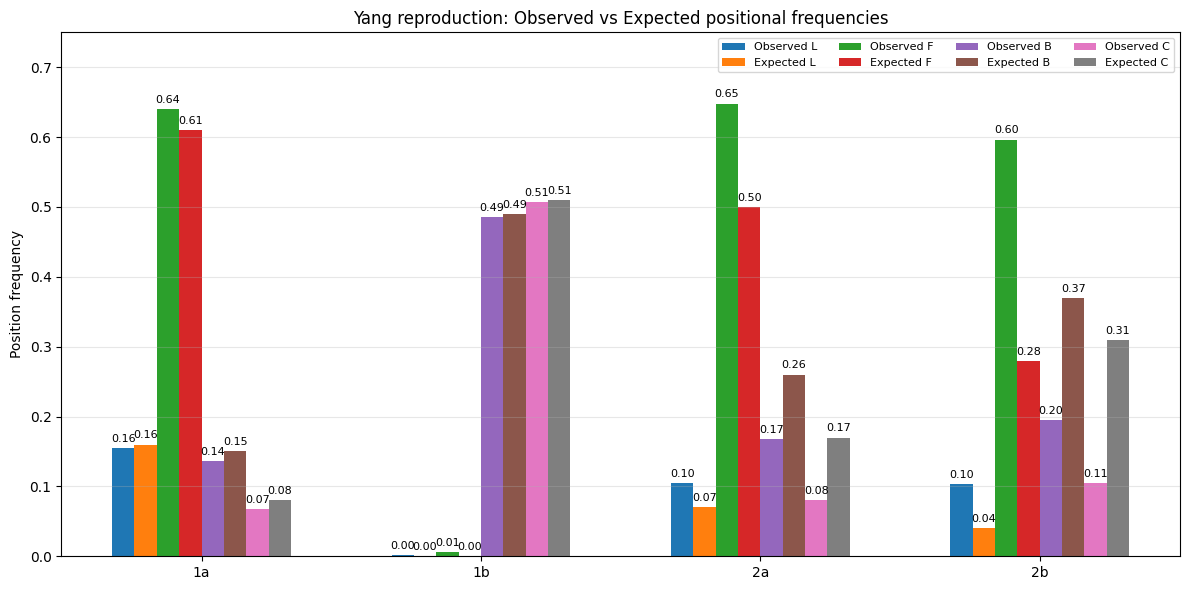

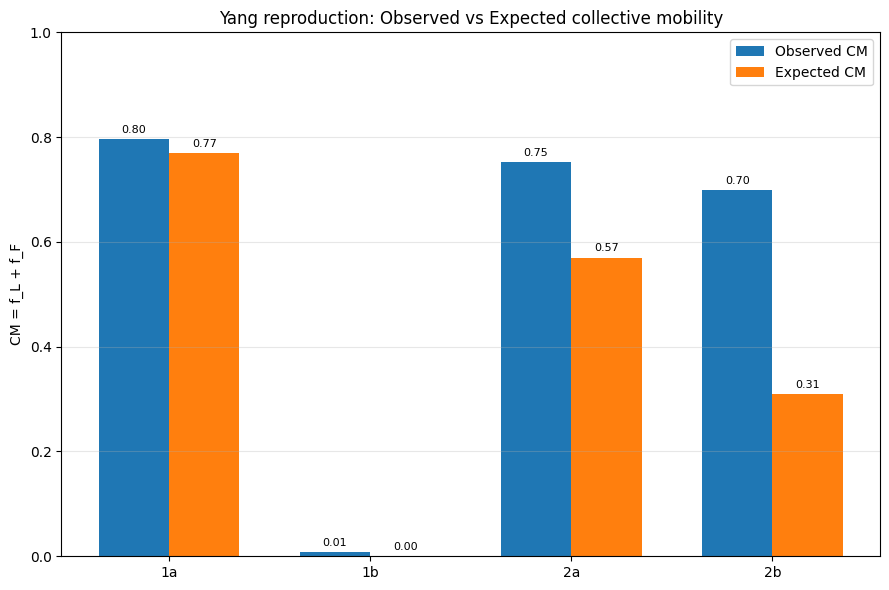

In [126]:
plot_strategy_comparison(RESULTS, "Yang reproduction", con1="Observed", con2="Expected")
plot_frequency_comparison(RESULTS, "Yang reproduction", con1="Observed", con2="Expected")
plot_cm_comparison(RESULTS, "Yang reproduction", con1="Observed", con2="Expected")

In [127]:
ALTERED_RESULTS = {
    "1A": {
        "observed_strategy": [],
        "expected_strategy": [],
        "observed_frequencies": [],
        "expected_frequencies": [],
        "observed_cm": 0,
        "expected_cm": 0,
    },
    "1B": {
        "observed_strategy": [],
        "expected_strategy": [],
        "observed_frequencies": [],
        "expected_frequencies": [],
        "observed_cm": 0,
        "expected_cm": 0,
    },
    "2A": {
        "observed_strategy": [],
        "expected_strategy": [],
        "observed_frequencies": [],
        "expected_frequencies": [],
        "observed_cm": 0,
        "expected_cm": 0,
    },
    "2B": {
        "observed_strategy": [],
        "expected_strategy": [],
        "observed_frequencies": [],
        "expected_frequencies": [],
        "observed_cm": 0,
        "expected_cm": 0,
    },
}

In [128]:
def get_runs(name):
    df = pd.read_csv(f"../results/g1000r3/{name}.csv")

    run0 = df[df["run"] == 0].reset_index()
    run1 = df[df["run"] == 1].reset_index()
    run2 = df[df["run"] == 2].reset_index()

    return run0, run1, run2

def fill_results_altered():
    # Ensure comparison between our Yang recreation and the altered baseline.
    for a, b in [("1a", "1A"), ("1b", "1B"), ("2a", "2A"), ("2b", "2B")]:
        ALTERED_RESULTS[b]["expected_strategy"] = RESULTS[a]["observed_strategy"]
        ALTERED_RESULTS[b]["expected_frequencies"] = RESULTS[a]["observed_frequencies"]
        ALTERED_RESULTS[b]["expected_cm"] = RESULTS[a]["observed_cm"]

    for name in ["1A", "1B", "2A", "2B"]:
        run0, run1, run2 = get_runs(name)

        avg_run = pd.DataFrame()
        avg_run["mean_p_L_given_F"] = pd.concat([run0["mean_p_L_given_F"], run1["mean_p_L_given_F"], run2["mean_p_L_given_F"]], axis=1).mean(axis=1)
        avg_run["mean_p_F_given_L"] = pd.concat([run0["mean_p_F_given_L"], run1["mean_p_F_given_L"], run2["mean_p_F_given_L"]], axis=1).mean(axis=1)
        avg_run["mean_p_L_given_B"] = pd.concat([run0["mean_p_L_given_B"], run1["mean_p_L_given_B"], run2["mean_p_L_given_B"]], axis=1).mean(axis=1)

        avg_run["f_L"] = pd.concat([run0["f_L"], run1["f_L"], run2["f_L"]], axis=1).mean(axis=1)
        avg_run["f_F"] = pd.concat([run0["f_F"], run1["f_F"], run2["f_F"]], axis=1).mean(axis=1)
        avg_run["f_B"] = pd.concat([run0["f_B"], run1["f_B"], run2["f_B"]], axis=1).mean(axis=1)
        avg_run["f_C"] = pd.concat([run0["f_C"], run1["f_C"], run2["f_C"]], axis=1).mean(axis=1)


        avg_run["CM"] = pd.concat([run0["CM"], run1["CM"], run2["CM"]], axis=1).mean(axis=1)

        ALTERED_RESULTS[name]["observed_strategy"].append(avg_run["mean_p_F_given_L"].iloc[-1])
        ALTERED_RESULTS[name]["observed_strategy"].append(avg_run["mean_p_L_given_F"].iloc[-1])
        ALTERED_RESULTS[name]["observed_strategy"].append(avg_run["mean_p_L_given_B"].iloc[-1])

        ALTERED_RESULTS[name]["observed_frequencies"].append(avg_run["f_L"].iloc[-1])
        ALTERED_RESULTS[name]["observed_frequencies"].append(avg_run["f_F"].iloc[-1])
        ALTERED_RESULTS[name]["observed_frequencies"].append(avg_run["f_B"].iloc[-1])
        ALTERED_RESULTS[name]["observed_frequencies"].append(avg_run["f_C"].iloc[-1])

        ALTERED_RESULTS[name]["observed_cm"] = avg_run["CM"].iloc[-1]

fill_results_altered()

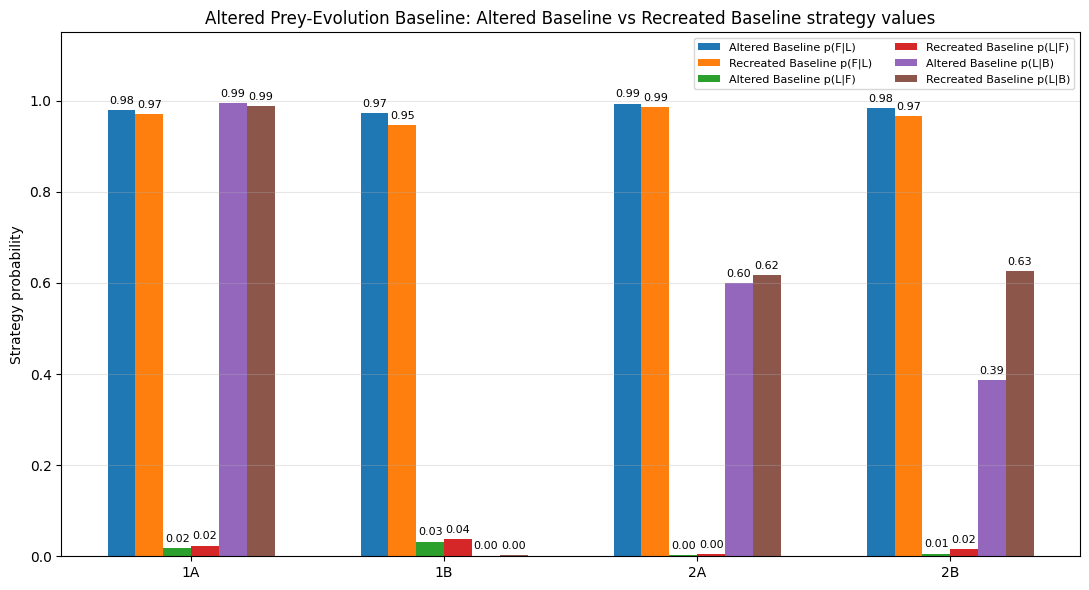

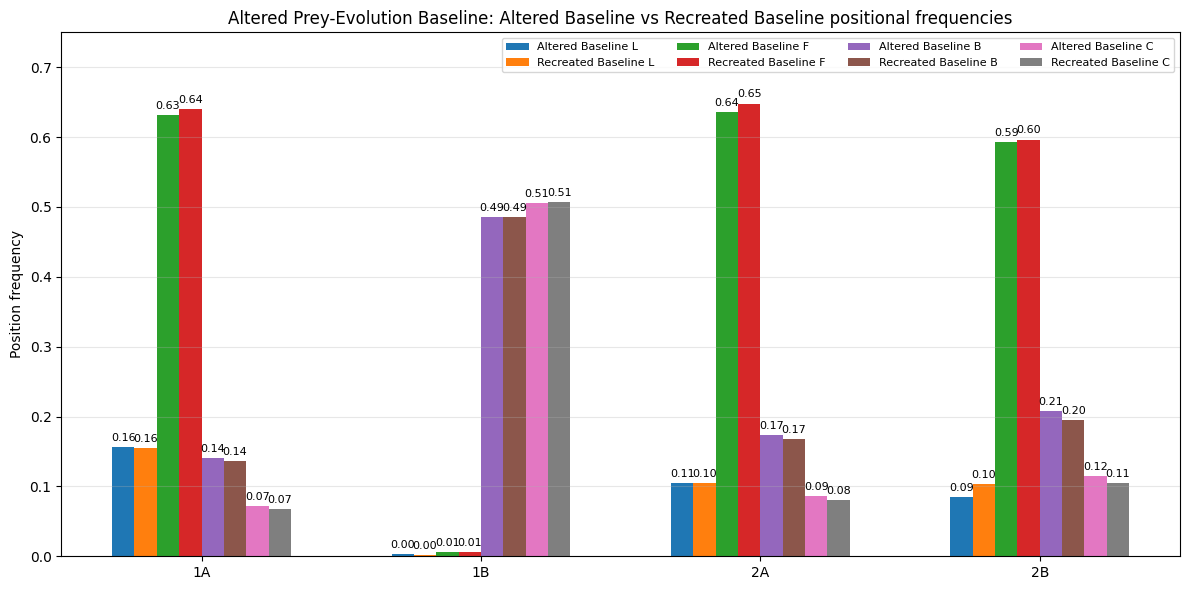

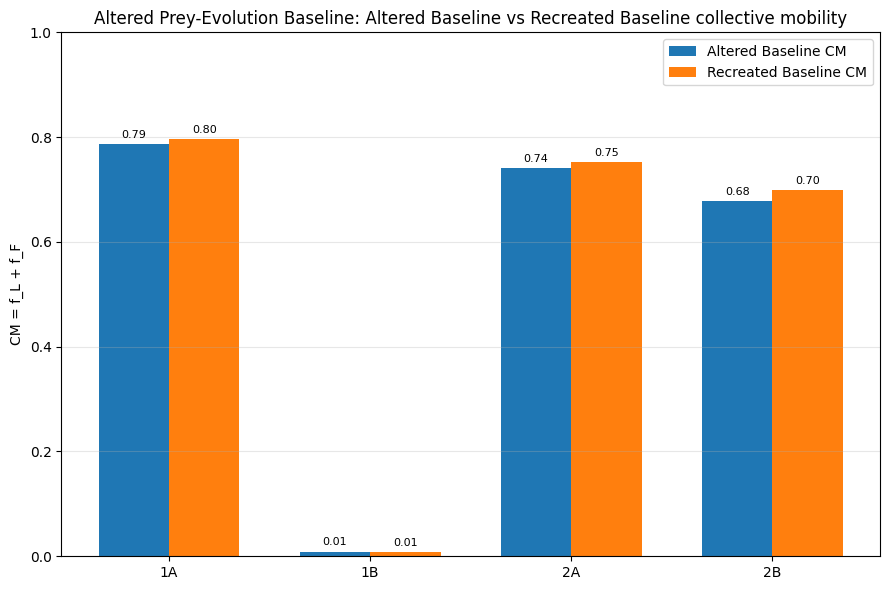

In [129]:
plot_strategy_comparison(ALTERED_RESULTS, "Altered Prey-Evolution Baseline", con1="Altered Baseline", con2="Recreated Baseline")
plot_frequency_comparison(ALTERED_RESULTS, "Altered Prey-Evolution Baseline", con1="Altered Baseline", con2="Recreated Baseline")
plot_cm_comparison(ALTERED_RESULTS, "Altered Prey-Evolution Baseline", con1="Altered Baseline", con2="Recreated Baseline")